In [1]:
import sys
sys.path.append(r"C:\\Users\\Lenovo\\Desktop")

In [2]:
from torch.utils.data import Dataset
from PIL import Image, UnidentifiedImageError
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim

In [3]:
class VideoFrameDataset(Dataset):
    def __init__(self, frame_root_dir, label_root_dir, transform=None):
        self.frame_root_dir = frame_root_dir
        self.transform = transform
        self.frames = []
        self.labels = []

        for video_folder in sorted(os.listdir(frame_root_dir)):
            video_path = os.path.join(frame_root_dir, video_folder)#Find the images
            label_file = os.path.join(label_root_dir, f'{video_folder}.txt')#Find the labels
            
            if not os.path.exists(label_file):#Skip if no label for the folder
                continue

            with open(label_file, 'r') as f:
                labels = f.readlines()

            labels = labels[1:]#Skip first line
            
            frame_files = sorted(os.listdir(video_path))
            frame_count = len(frame_files)
            label_count = len(labels)
            count = min(frame_count, label_count)
            print(f"Processing {count} frames and labels for video {video_folder}")

            for i in range(count):
                frame_name = frame_files[i]
                frame_path = os.path.join(video_path, frame_name)
                label_parts = labels[i].strip().split(',')
                valence = label_parts[0]
                arousal = label_parts[1]

                if valence == '-5' or arousal == '-5':#Drop the data with label=-5
                    continue

                self.frames.append(frame_path)
                self.labels.append([float(valence), float(arousal)])

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx, retry=0):
        try:
            image = Image.open(self.frames[idx])
            label = self.labels[idx]

            if self.transform:
                image = self.transform(image)

            label_tensor = torch.tensor(label)
            return image, label_tensor
        except UnidentifiedImageError:
            if retry < len(self.frames) - 1:
                return self.__getitem__((idx + 1) % len(self.frames), retry + 1)
            else:
                raise RuntimeError("Too many corrupted images, cannot provide a valid batch")



train_transforms  = transforms.Compose([
        transforms.Resize(224),
        # transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(p=0.3),#Flip some images randomly
        transforms.RandomPerspective(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
test_transforms = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

train_dataset = VideoFrameDataset(frame_root_dir='F:\\Aff-Wild2\\Model\\data1', label_root_dir='F:\\Aff-Wild2\\5th_ABAW_Annotations\\mini_va\\train', transform=train_transforms)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = VideoFrameDataset(frame_root_dir='F:\\Aff-Wild2\\Model\\data1', label_root_dir='F:\\Aff-Wild2\\5th_ABAW_Annotations\\mini_va\\valid', transform=test_transforms)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


Processing 2501 frames and labels for video 10-60-1280x720
Processing 2639 frames and labels for video 100-29-1080x1920
Processing 5153 frames and labels for video 101-30-1080x1920
Processing 2425 frames and labels for video 104-17-720x480
Processing 10076 frames and labels for video 105
Processing 8163 frames and labels for video 106
Processing 1404 frames and labels for video 106-30-720x1280
Processing 5315 frames and labels for video 107
Processing 4678 frames and labels for video 108
Processing 5504 frames and labels for video 110
Processing 9978 frames and labels for video 110-30-270x480
Processing 7246 frames and labels for video 111
Processing 771 frames and labels for video 111-25-1920x1080
Processing 5915 frames and labels for video 112
Processing 15020 frames and labels for video 113
Processing 2449 frames and labels for video 114
Processing 2517 frames and labels for video 116
Processing 6183 frames and labels for video 116-30-1280x720
Processing 4081 frames and labels for v

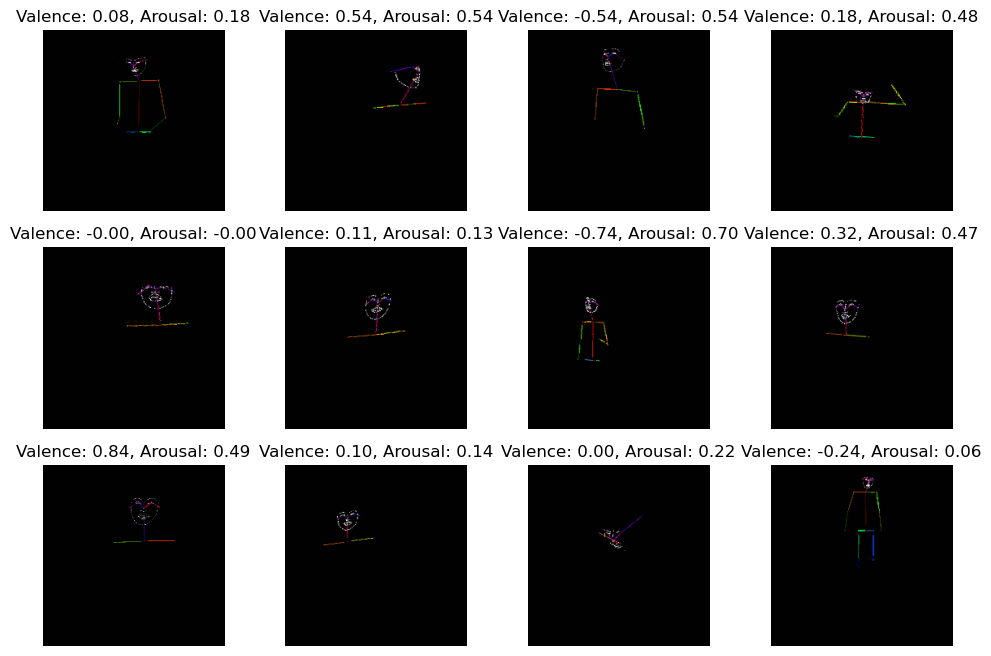

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(dataloader):
    images, labels = next(iter(dataloader))
    images = images.numpy()
    labels = labels.numpy()

    fig, axes = plt.subplots(figsize=(12, 8), nrows=3, ncols=4)
    for i, ax in enumerate(axes.flat):
        if i >= images.shape[0]:
            break
        img = np.transpose(images[i], (1, 2, 0))
        img = (img * 255).astype(np.uint8)
        ax.imshow(img)
        ax.set_title(f'Valence: {labels[i][0]:.2f}, Arousal: {labels[i][1]:.2f}')
        ax.axis('off')

    plt.show()
    
show_batch(train_loader)

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = torch.device('cpu')
print(device)

cuda


In [6]:
def he_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [ ]:
# from torchvision import models
# model = models.resnet50(pretrained=True)#Set to ResNet50
# model = models.densenet121(pretrained=True)#Set to DenseNet121
# num_features = model.fc.in_features
# model.fc = torch.nn.Linear(num_features, 7)#Set output channel to7 for classification, set to 2 for valence and arousal

In [7]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample):
        super().__init__()
        if downsample:# if downsample is true, will raise skip connection. will correspond the input and output channels
            self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
            self.shortcut = nn.Sequential()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.drop = nn.Dropout(0.2)

    def forward(self, input):
        shortcut = self.shortcut(input)
        input = nn.ReLU()(self.bn1(self.conv1(input)))
        input = nn.ReLU()(self.bn2(self.conv2(input)))
        # input = self.drop(input)
        input = input + shortcut
        return nn.ReLU()(input)

class ResNet18(nn.Module):
    def __init__(self, in_channels, resblock, outputs=7):
        super().__init__()
        self.layer0 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3),
            # nn.Conv2d(in_channels, 64, kernel_size=3, stride=2, padding=1),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.layer1 = nn.Sequential(
            resblock(64, 64, downsample=False),
            resblock(64, 64, downsample=False),
            nn.AvgPool2d(2),
        )

        self.layer2 = nn.Sequential(
            resblock(64, 128, downsample=True),
            resblock(128, 128, downsample=False),
            nn.AvgPool2d(2),
        )

        self.layer3 = nn.Sequential(
            resblock(128, 256, downsample=True),
            resblock(256, 256, downsample=False),
            nn.AvgPool2d(2),
        )


        self.layer4 = nn.Sequential(
            resblock(256, 512, downsample=True),
            resblock(512, 512, downsample=False)
        )

        self.gap = torch.nn.AdaptiveAvgPool2d(1)# global average pooliing
        self.classifier = nn.Sequential(
            # nn.AvgPool2d(2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, outputs)
        )

    def forward(self, input):
        input = self.layer0(input)
        input = self.layer1(input)
        input = self.layer2(input)
        input = self.layer3(input)
        input = self.layer4(input)
        input = self.gap(input)
        input = torch.flatten(input, start_dim=1)
        input = self.classifier(input)

        return input

model = ResNet18(3, ResBlock, outputs=7)#Set output channel to7 for classification, set to 2 for valence and arousal
model.to(torch.device("cuda:0" if torch.cuda.is_available() else "cpu"))

ResNet18(
  (layer0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
  )
  (layer1): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (shortcut): Sequential()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop): Dropout(p=0.2, inplace=False)
    )
    (1): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (shortcut): Sequential()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): Ba

In [8]:
# model.apply(he_init)


num_epochs = 10
lr = 1e-4
weight_decay = 5e-3

loss = nn.MSELoss()# For regrasion task

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

In [9]:
model = model.to(device)
print(next(model.parameters()).device)
print(torch.cuda.is_available())  # Should return True if CUDA is available
print(torch.cuda.current_device())  # Returns the index of the current device
print(torch.cuda.get_device_name(torch.cuda.current_device()))  # Returns the name of the current device



cuda:0
True
0
NVIDIA GeForce RTX 3060 Laptop GPU


In [10]:
def ccc(y_true, y_pred):
    mean_true = torch.mean(y_true)
    mean_pred = torch.mean(y_pred)
    var_true = torch.var(y_true)
    var_pred = torch.var(y_pred)
    covariance = torch.mean((y_true - mean_true) * (y_pred - mean_pred))
    ccc = 2 * covariance / (var_true + var_pred + (mean_true - mean_pred) ** 2)
    return ccc


In [11]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=10):
    train_losses, val_losses = [], []
    train_cccs, val_cccs = [], []
    # Initialize lists to store loss and CCC metrics for training and validation phases

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_ccc = 0.0
            num_samples = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)# Move input and labels to cuda

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    ccc_score = ccc(labels, outputs).item()

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Accumulate loss and CCC, and count samples for averaging
                running_loss += loss.item() * inputs.size(0)
                running_ccc += ccc_score * inputs.size(0)
                num_samples += inputs.size(0)
            
            # Calculate average loss and CCC for the epoch
            epoch_loss = running_loss / num_samples
            epoch_ccc = running_ccc / num_samples

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_cccs.append(epoch_ccc)
            else:
                val_losses.append(epoch_loss)
                val_cccs.append(epoch_ccc)

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f}')
            print(f'{phase.capitalize()} CCC: {epoch_ccc:.4f}')

    return train_losses, val_losses, train_cccs, val_cccs


Epoch 1/5
----------
Train Loss: 0.1120
Train CCC: 0.4852
Val Loss: 0.6872
Val CCC: 0.2133
Epoch 2/5
----------
Train Loss: 0.0985
Train CCC: 0.5652
Val Loss: 0.2265
Val CCC: 0.2585
Epoch 3/5
----------
Train Loss: 0.0901
Train CCC: 0.6129
Val Loss: 0.1599
Val CCC: 0.1039
Epoch 4/5
----------
Train Loss: 0.0858
Train CCC: 0.6378
Val Loss: 0.2442
Val CCC: 0.0302
Epoch 5/5
----------
Train Loss: 0.0832
Train CCC: 0.6524
Val Loss: 0.1674
Val CCC: 0.0858


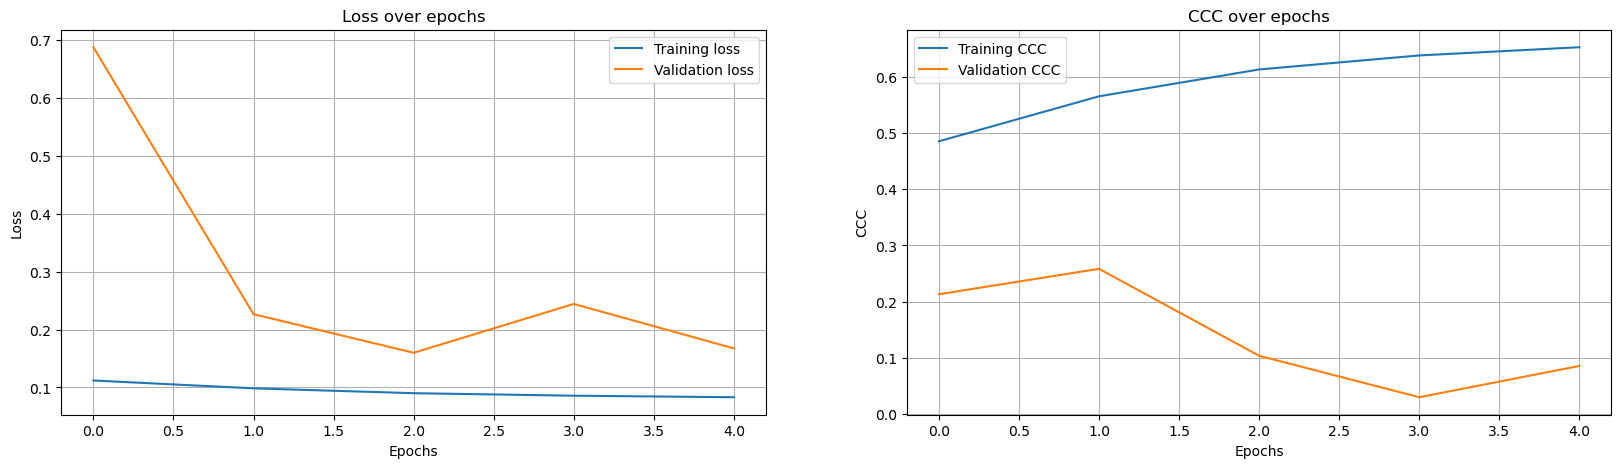

In [12]:
def plot_losses(train_losses, val_losses, train_cccs, val_cccs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
    
    ax1.plot(train_losses, label='Training loss')
    ax1.plot(val_losses, label='Validation loss')
    ax1.set_title('Loss over epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(train_cccs, label='Training CCC')
    ax2.plot(val_cccs, label='Validation CCC')
    ax2.set_title('CCC over epochs')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('CCC')
    ax2.legend()
    ax2.grid(True)

    plt.show()
    
dataloaders = {'train': train_loader, 'val': val_loader}
train_losses, val_losses, train_cccs, val_cccs = train_model(model, dataloaders, loss, optimizer, num_epochs=5)
plot_losses(train_losses, val_losses, train_cccs, val_cccs)


Epoch 1/5
----------
Train Loss: 0.0781
Train CCC: 0.6725
Val Loss: 0.1734
Val CCC: 0.1775
Epoch 2/5
----------
Train Loss: 0.0763
Train CCC: 0.6838
Val Loss: 0.1767
Val CCC: 0.1815
Epoch 3/5
----------
Train Loss: 0.0754
Train CCC: 0.6894
Val Loss: 0.1761
Val CCC: 0.1740
Epoch 4/5
----------
Train Loss: 0.0748
Train CCC: 0.6934
Val Loss: 0.1787
Val CCC: 0.1675
Epoch 5/5
----------
Train Loss: 0.0742
Train CCC: 0.6964
Val Loss: 0.1775
Val CCC: 0.1742


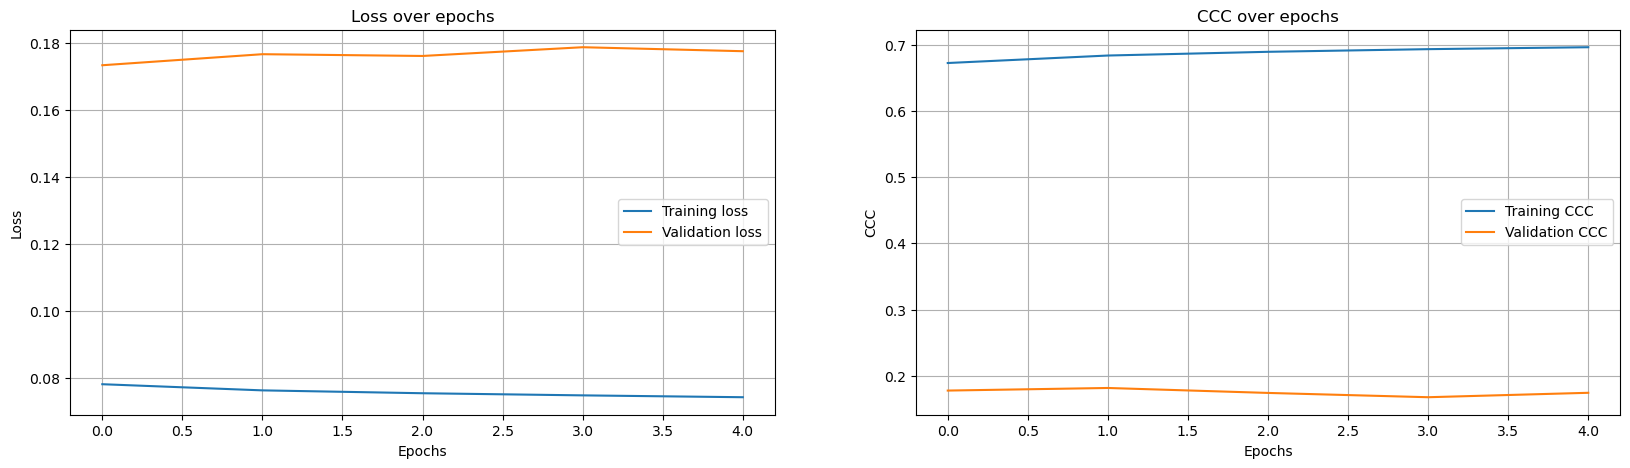

In [15]:
optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)#Change optimizer
train_losses, val_losses, train_cccs, val_cccs = train_model(model, dataloaders, loss, optimizer, num_epochs=5)
plot_losses(train_losses, val_losses, train_cccs, val_cccs)

In [14]:
test_dataset = VideoFrameDataset(frame_root_dir='F:\\Aff-Wild2\\Model\\data1', label_root_dir='F:\\Aff-Wild2\\5th_ABAW_Annotations\\mini_va\\valid-1', transform=test_transforms)
test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
def validate(model, dataloader):
    total_loss = 0
    criterion = nn.MSELoss()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

    average_loss = total_loss / len(dataloader)
    print(f'Validation Loss: {average_loss:.4f}')

validate(model, test_loader)


Validation Loss: 0.1674
